In [3]:
from OptimalBattery import simulate as sim
import numpy as np
import matplotlib.pyplot as plt
import HierarchBayesParcel.evaluation as ev
import torch as pt
import OptimalBattery.util as ut
from numpy.linalg import eigh
from scipy.stats import pearsonr
from Functional_Fusion.dataset import DataSetMDTB
import PcmPy as pcm
import seaborn as sns
import os
import pandas as pd
import pickle
from HierarchBayesParcel.util import indicator
import HierarchBayesParcel.emissions as em
import HierarchBayesParcel.full_model as fm
from IndividualParcellation.evaluate import calc_test_dcbc
from DCBC.utilities import compute_dist
import Functional_Fusion.atlas_map as am
from HierarchBayesParcel.evaluation import calc_test_error
import HierarchBayesParcel.arrangements as ar
import nitools as nt
from IndividualParcellation.global_config import *
from OptimalBattery.plot import plot_correlations

In [28]:
atlas,_= am.get_atlas(atlas_str='SUIT3')

In [29]:
prob_parcel_dir = 'Y:/data/Cerebellum/Language/ProbabilisticParcellations/'
if not os.path.exists(prob_parcel_dir):
    prob_parcel_dir = '/cifs/diedrichsen/data/Cerebellum/Language/ProbabilisticParcellations/'
# load model pkl
with open(f'{prob_parcel_dir}/mdtb-s1_mdtb-s2_fusion_k4_SUIT3.pkl', 'rb') as f:
    full_model = pickle.load(f)

In [30]:
ar_model_logpi = full_model.arrange.logpi
# move to gpu
ar_model_logpi = ar_model_logpi.to(DEVICE)

In [31]:
# Make an arrangement model (from group prior)
ar_model = ar.build_arrangement_model(ar_model_logpi, prior_type='logpi', atlas=atlas,
                                        sym_type='asym')

In [32]:
# load emission model & Vs for mdtb ses-1
mdtb_1_emission = full_model.emissions[0]
mdtb_1_Vs = mdtb_1_emission.V

#make into np array
VL_mdtb = mdtb_1_Vs.detach().numpy()
GL_mdtb = VL_mdtb @ VL_mdtb.T

mdtb_2_emission = full_model.emissions[1]
mdtb_2_Vs = mdtb_2_emission.V

#make into np array
VL_mdtb_2 = mdtb_2_Vs.detach().numpy()
GL_mdtb_2 = VL_mdtb_2 @ VL_mdtb_2.T

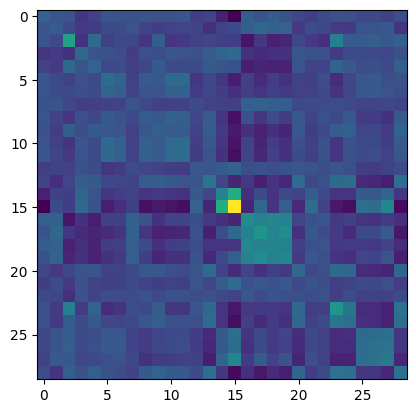

In [33]:
plt.imshow(GL_mdtb)

In [34]:
MDTB_dataset = DataSetMDTB('/cifs/diedrichsen/data/FunctionalFusion/MDTB')
if not os.path.exists('/cifs/diedrichsen/data/FunctionalFusion/MDTB'):
    MDTB_dataset = DataSetMDTB('Y:/data/FunctionalFusion/MDTB')

data_mdtb_s1_run,info_mdtb_1_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s1',type='CondRun')
data_mdtb_s1_run[np.isnan(data_mdtb_s1_run)] = 0


data_mdtb_s2_run,info_mdtb_2_run  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondRun')
data_mdtb_s2_run[np.isnan(data_mdtb_s2_run)] = 0

data_mdtb_s2_all,info_mdtb_2_all  =MDTB_dataset.get_data(space='SUIT3',ses_id='ses-s2',type='CondAll')
data_mdtb_s2_all[np.isnan(data_mdtb_s2_all)] = 0


In [35]:
def HBP_u(train_data,cond_vec,part_vec):
    x_matrix = indicator(cond_vec)
    
    
    em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec,
                         subject_specific_kappa=False, parcel_specific_kappa=False, 
                         subjects_equal_weight=True)
    
    M_1 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
    M_1.initialize([train_data])

    M_1, ll,_,U_individual = M_1.fit_em(iter=200, tol=0.01,
                                     fit_arrangement=False,
                                     fit_emission= True,
                                     first_evidence=False)    

    # Get the data-only parcellation
    emloglik = M_1.emissions[0].Estep()
    U_data = pt.softmax(emloglik, dim=1) # get data only parcellation
    kappa = M_1.emissions[0].kappa

    return U_data,kappa

In [36]:
def projection_U(Vs,Y):
    U = Vs.T @ Y
    return U


In [37]:
def evaluate_cos(D, ytrain,info, Vs,ytest_run, vtest,M_test):
    # Create a new column with combinations as tuples to make them hashable
    D['combination_tuple'] = D['combination'].apply(lambda x: tuple(x))
    
    # Get unique combinations
    unique_combinations = D['combination_tuple'].unique()
    
    # Initialize a dictionary to store cos_HBP for each unique combination
    cos_HBP_dict = {}

    ytest_run = pt.tensor(ytest_run,dtype=pt.float32)
    vtest = pt.tensor(vtest,dtype=pt.float32)

    U_list = []
    
    # Loop over each unique combination
    for i, comb_tuple in enumerate(unique_combinations):
        print(f"Processing combination: {i}")
        
        # Get the task subset indices and corresponding data
        task_subset_indices = list(comb_tuple)

        V_subset = Vs[task_subset_indices, :]
        V_subset = V_subset - np.mean(V_subset, axis=0)
        V_subset = V_subset / np.linalg.norm(V_subset, axis=0)


        y_subset = ytrain[:, task_subset_indices, :]
        y_subset = y_subset - np.mean(y_subset, axis=0)
        y_subset = y_subset / np.linalg.norm(y_subset, axis=0)


        # leverage repeats for HBP
        HBP_data,HBP_cond_vec,HBP_part_vec = ut.make_dataset(ytrain,info,task_subset_indices,n_repeats=3)
        U_hat_HBP ,kappa = HBP_u(HBP_data, HBP_cond_vec, HBP_part_vec)
        U_list.append(U_hat_HBP)
        U_hat_HBP = [U_hat_HBP]
        kappa = kappa.item()     
        
        # Compute cos_HBP
        cos_HBP = calc_test_error(M=M_test, tdata=ytest_run, U_hats=U_hat_HBP, fit_emission='use_Uhats').mean()
        
        # Store the result in the dictionary
        cos_HBP_dict[comb_tuple] = cos_HBP
    
    # Map the computed cos_HBP values back to the DataFrame
    D['cos_HBP'] = D['combination_tuple'].map(cos_HBP_dict)
    
    return D

In [38]:
cond_vec_test = np.tile(np.arange(1, 32 + 1), 16)
part_vec_test = np.repeat(np.arange(1, 16 + 1), 32)
data_test = data_mdtb_s2_run


x_matrix = indicator(cond_vec_test)


em_model = em.MixVMF(K=4, P=6918, X=x_matrix, part_vec=part_vec_test,
                    subject_specific_kappa=False, parcel_specific_kappa=False, 
                    subjects_equal_weight=True)

M_2 = fm.FullMultiModel(arrange=ar_model, emission=[em_model])
M_2.initialize([data_test])

M_2, ll,_,U_individual = M_2.fit_em(iter=200, tol=0.01,
                                fit_arrangement=False,
                                fit_emission= True,
                                first_evidence=False)    


Likelihood decreased - terminating on iteration 20


In [39]:
offsets = [1e-10,1e-8,1e-6,1e-4,1e-2,1,1e2,1e4,1e6,1e8,1e10]
D_mdtb = ut.build_combinations(GL_mdtb, strategy='random',offs = offsets,n_iter=30,n_tasks=8,seed=3)
D_mdtb = evaluate_cos(D_mdtb, data_mdtb_s1_run,info_mdtb_1_run,VL_mdtb,data_mdtb_s2_run, VL_mdtb_2,M_2)


building0
Processing combination: 0
Subject:0:1.0160s
Subject:1:0.8763s
Subject:2:0.7720s
Subject:3:0.7521s
Subject:4:0.7666s
Subject:5:0.7113s
Subject:6:0.7078s
Subject:7:0.7778s
Subject:8:0.7769s
Subject:9:0.8117s
Subject:10:0.9087s
Subject:11:0.9575s
Subject:12:0.7338s
Subject:13:0.7310s
Subject:14:0.7511s
Subject:15:0.8855s
Subject:16:0.8062s
Subject:17:0.7984s
Subject:18:0.7766s
Subject:19:0.7289s
Subject:20:0.7369s
Subject:21:0.7436s
Subject:22:0.7466s
Subject:23:0.8899s
Processing combination: 1
Subject:0:0.7512s
Subject:1:0.6902s
Subject:2:0.8536s
Subject:3:0.8971s
Subject:4:1.0058s
Subject:5:0.8825s
Subject:6:1.0634s
Subject:7:0.7993s
Subject:8:0.8085s
Subject:9:0.7457s
Subject:10:0.9876s
Subject:11:0.7386s
Subject:12:1.0636s
Subject:13:1.1353s
Subject:14:1.3917s
Subject:15:1.1578s
Subject:16:0.9478s
Subject:17:1.2377s
Subject:18:1.3121s
Subject:19:1.2423s
Subject:20:0.9078s
Subject:21:1.1643s
Subject:22:0.9732s
Subject:23:0.8176s
Processing combination: 2
Likelihood decreased

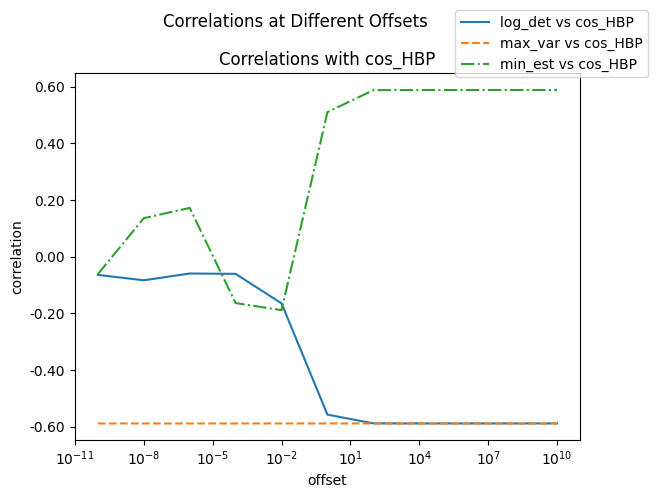

In [40]:
plot_correlations(D_mdtb, x_vars=['log_det','max_var','min_est'], y_vars=['cos_HBP'])